<a href="https://colab.research.google.com/github/ayatayoub20/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Product Sales


- Author: Ayat Ayoub

## Project Overview


## Load and Inspect Data


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv')

# Preview data
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## Clean Data



1) How many rows and columns?

In [2]:
df.shape

(8523, 12)

2) What are the datatypes of each variable?

In [3]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


3) Are there duplicates?

In [4]:
float(df.duplicated().sum())

0.0

4) Identify missing values

In [5]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


5) Address missing values using placeholder value

In [6]:
df['Outlet_Size'] = df['Outlet_Size'].fillna('Unknown')

In [7]:
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

6) Confirm no missing values

In [8]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


7) Fix inconsistent categories

In [9]:
df['Item_Fat_Content'].value_counts()
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

In [10]:
df['Item_Fat_Content'].value_counts()


,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


8) Summary statistics for numerical columns

In [11]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [12]:
df[['Item_Weight','Item_Visibility','Item_MRP','Item_Outlet_Sales']].agg(['min','max','mean'])

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales
min,4.555000,0.000000,31.290000,33.290000
max,21.350000,0.328391,266.888400,13086.964800
mean,12.857645,0.066132,140.992782,2181.288914


## Exploratory Data Analysis


**1) Histogram section**

This plot displays the distribution of product sales.

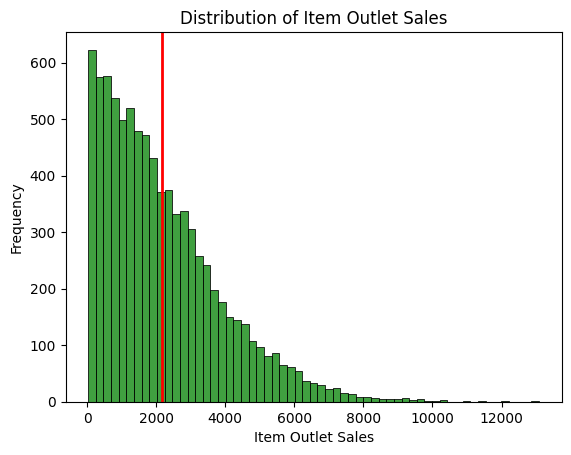

In [13]:
#Distribution of Item Outlet Sales by histogram
mean = df['Item_Outlet_Sales'].mean()
ax = sns.histplot(data=df,x='Item_Outlet_Sales',color='green')
ax.axvline(mean,color='red',linewidth=2);
ax.set_title('Distribution of Item Outlet Sales');
ax.set_xlabel('Item Outlet Sales');
ax.set_ylabel('Frequency');

The distribution is right-skewed, with most products having low to moderate sales, and a small number of products having very high sales. The mean is higher than most values due to these high outliers.

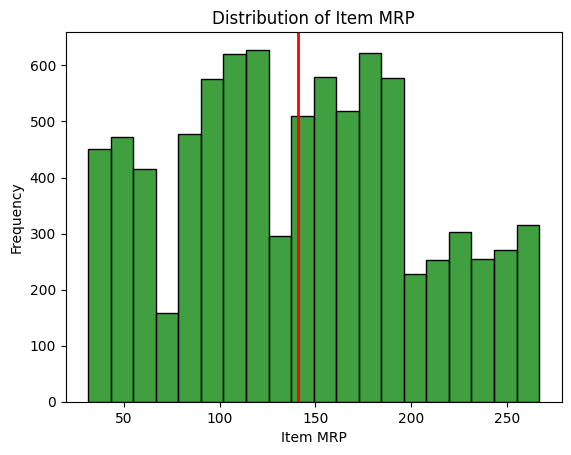

In [17]:
mean = df['Item_MRP'].mean()
ax = sns.histplot(data=df,x='Item_MRP',color='green',bins=20)
ax.axvline(mean,color='red',linewidth=2);
ax.set_title('Distribution of Item MRP');
ax.set_xlabel('Item MRP');
ax.set_ylabel('Frequency');

Item_MRP is concentrated around the middle price range, suggesting that most products are moderately priced.

**2) Boxplot section**

/tmp/ipykernel_4727/3084735285.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45);


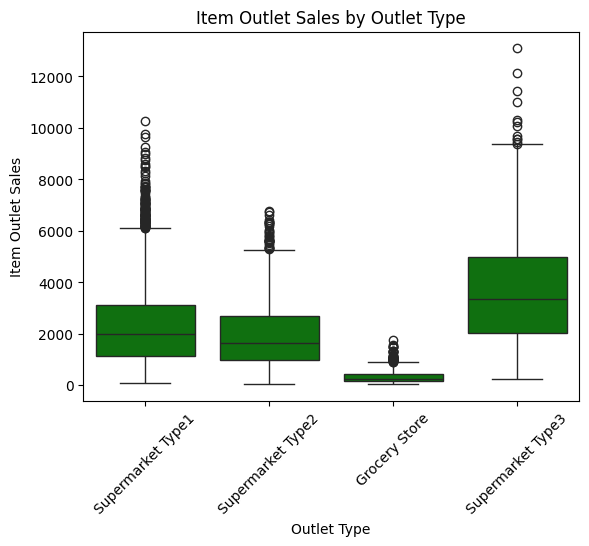

In [30]:
ax = sns.boxplot(data=df,x='Outlet_Type',y='Item_Outlet_Sales',color='green');
ax.set_xticklabels(ax.get_xticklabels(),rotation=45);
ax.set_title('Item Outlet Sales by Outlet Type');
ax.set_xlabel('Outlet Type');
ax.set_ylabel('Item Outlet Sales');



Item outlet sales vary significantly across outlet types. Supermarket Type3 has the highest sales, while Grocery Stores have the lowest, suggesting that store type strongly influences sales performance.

/tmp/ipykernel_4727/2004735174.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha='right');


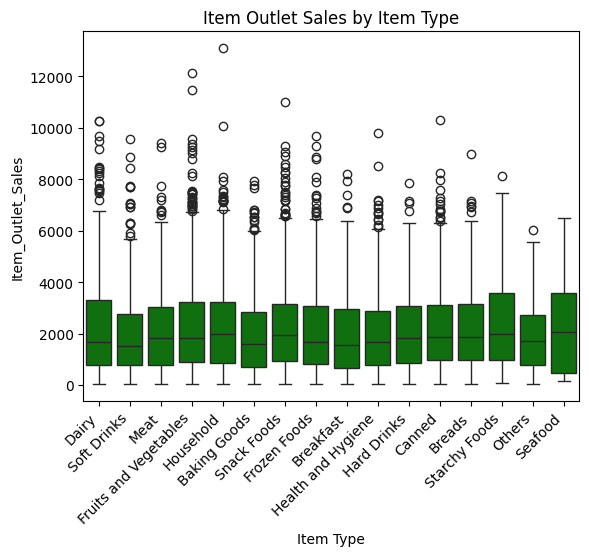

In [25]:
ax = sns.boxplot(data=df,x='Item_Type',y='Item_Outlet_Sales',color='green');
ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha='right');
ax.set_title('Item Outlet Sales by Item Type');
ax.set_xlabel('Item Type');

Sales are relatively similar across different item types, with no major differences between categories. This suggests that product type has a smaller impact on sales compared to other factors.

**3) Countplot section**

/tmp/ipykernel_4727/2434891732.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45);


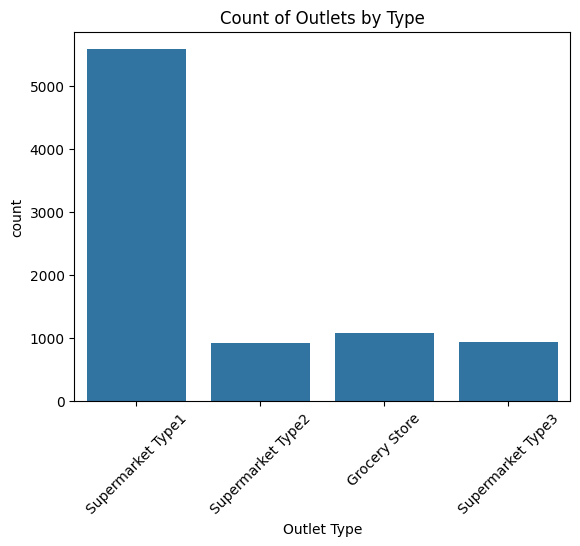

In [34]:
ax = sns.countplot(data=df, x='Outlet_Type');
ax.set_xticklabels(ax.get_xticklabels(),rotation=45);
ax.set_title('Count of Outlets by Type');
ax.set_xlabel('Outlet Type');

In [ ]:
corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='Greens')
plt.title('Correlation Heatmap')

## Future Inspection
